# 6. Análisis bidimensional (sección 2.3)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Estructura (misma lógica que las notas de clase 9.10.4.1.3, generalizada de
un objetivo binario a 6 clases ordinales):

| Par de variables | Gráfico | Prueba / medida | Tamaño de efecto |
|---|---|---|---|
| numérica – numérica | hexbin | Pearson y Spearman | \|r\| y \|Pearson − Spearman\| |
| numérica – objetivo | violín / boxplot | Kruskal-Wallis (alternativa no paramétrica al ANOVA) | η²_H, Spearman |
| categórica – objetivo | barras apiladas | χ² | V de Cramér |
| categórica – categórica | tabla de contingencia | χ² | V de Cramér |
| cualquiera – objetivo | — | información mutua (no lineal) | MI / H(Y) |
| multicolinealidad | heatmap | VIF | VIF |

**Rigor estadístico.** Con n ≈ 220 000 casi toda diferencia es
"significativa", así que la conclusión se basa en el **tamaño de efecto** y
los p-valores se corrigen por comparaciones múltiples (**Holm**). Además,
estas pruebas suponen filas **independientes**, y aquí no lo son (unidades
del mismo edificio, autocorrelación espacial fuerte): los p-valores son
anticonservadores (demasiado pequeños). Por eso **las conclusiones se apoyan
en los tamaños de efecto**, no en la significancia.

In [1]:
# Celda de preparación: rutas, librerías, estilo y carga de train. Como en todo
# el EDA, solo se usa la partición de entrenamiento para que ninguna decisión
# (selección de variables, VIF, etc.) se contamine con información de test.
import sys
import warnings
from pathlib import Path

# Raíz del libro (carpeta padre si se ejecuta desde notebooks/) para importar src.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)  # avisos de versión, no de resultados

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

from src import config as C
from src import espacial as S
from src import estadistica as E
from src import graficos as G
from src import particion as P

G.estilo()
C.aviso_sintetico()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_columns", 30)
train = P.cargar_particion(solo="train")
# Decisiones registradas en capítulos anteriores (decisiones_eda.json); aquí
# interesa la lista de variables que se transforman con log1p (cap. 5.5).
dec = C.leer_decisiones()
nums = [c for c in C.NUMERICAS if c in train]
# Se excluyen las categóricas constantes (p. ej. tipo_planta): con una sola
# categoría la χ² y la V de Cramér no están definidas.
cats = [c for c in C.CATEGORICAS if c in train and train[c].nunique() > 1]
# .get(..., {}) permite ejecutar el notebook aunque el cap. 5 no haya corrido.
num_log = dec.get("num_log", {}).get("valor", [])

## 6.1 Numéricas vs. numéricas

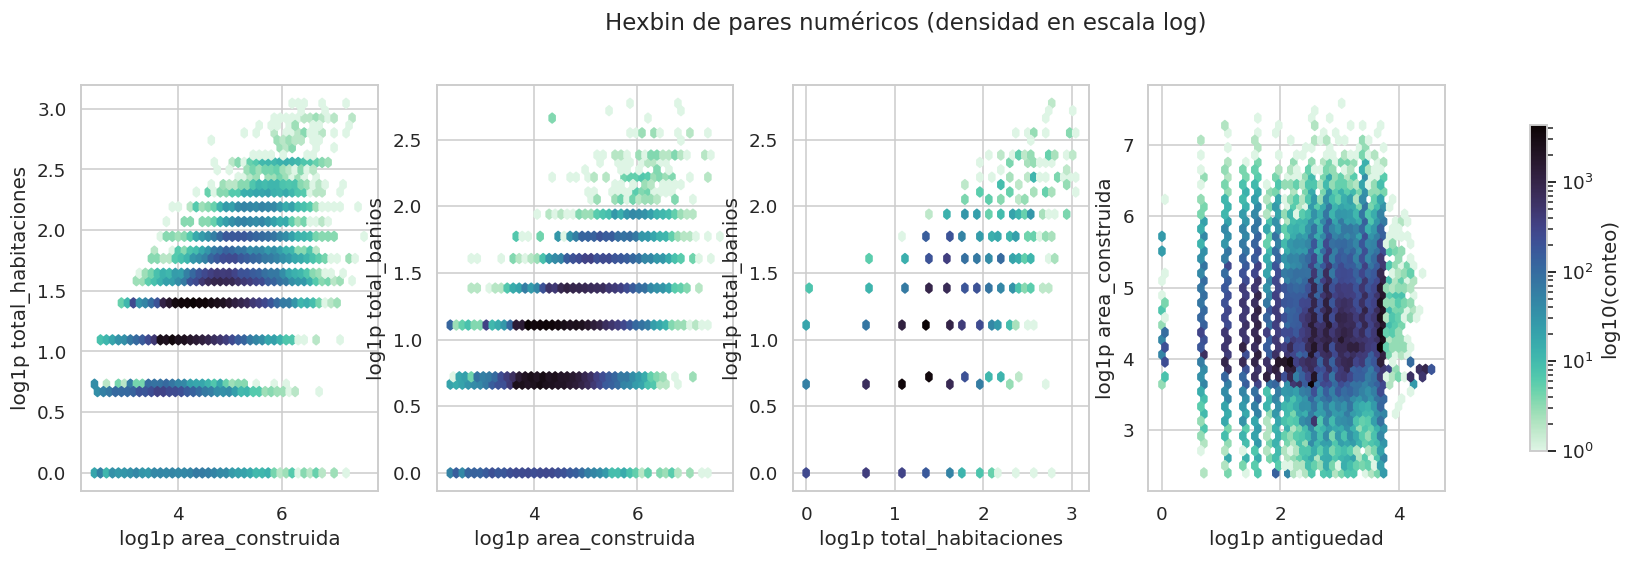

In [2]:
# Figura: hexbin de cuatro pares numéricos con sentido físico (área frente a
# habitaciones y baños, etc.). Con ~220 000 puntos un scatter se satura; el
# hexbin muestra la densidad. Las variables asimétricas se grafican en log1p,
# la misma escala en que entran al modelo.
pares = [("area_construida", "total_habitaciones"), ("area_construida", "total_banios"),
         ("total_habitaciones", "total_banios"), ("antiguedad", "area_construida")]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, (a, b) in zip(axes, pares):
    d = train[[a, b]].dropna()
    xa = np.log1p(d[a]) if a in num_log else d[a]
    xb = np.log1p(d[b]) if b in num_log else d[b]
    # bins="log": color en log10(conteo), para que se vean tanto las celdas muy
    # densas como las poco pobladas; mincnt=1 deja en blanco las celdas vacías.
    hb = ax.hexbin(xa, xb, gridsize=45, bins="log", cmap="mako_r", mincnt=1)
    ax.set_xlabel(("log1p " if a in num_log else "") + a)
    ax.set_ylabel(("log1p " if b in num_log else "") + b)
fig.colorbar(hb, ax=axes, label="log10(conteo)", shrink=0.8)
fig.suptitle("Hexbin de pares numéricos (densidad en escala log)", y=1.02)
G.guardar(fig, "06_hexbin")
plt.show()

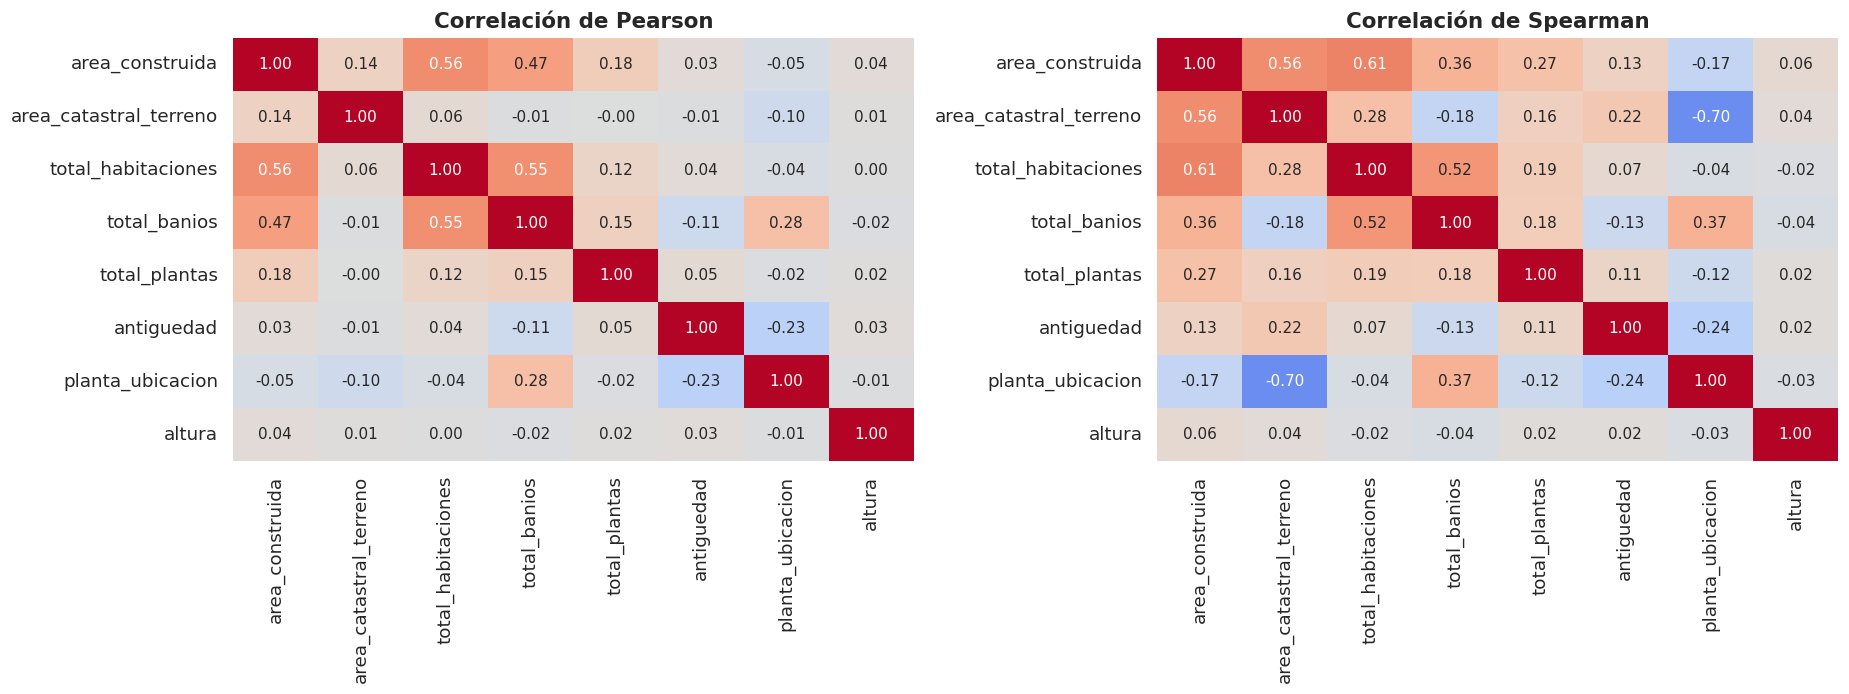

,var1,var2,pearson,spearman,|dif|,lectura
11,area_catastral_terreno,planta_ubicacion,-0.102,-0.695,0.593,notable -> no lineal u outliers (priorizar Spe...
0,area_construida,area_catastral_terreno,0.139,0.560,0.421,notable -> no lineal u outliers (priorizar Spe...
10,area_catastral_terreno,antiguedad,-0.011,0.222,0.233,notable -> no lineal u outliers (priorizar Spe...
7,area_catastral_terreno,total_habitaciones,0.058,0.281,0.223,notable -> no lineal u outliers (priorizar Spe...
8,area_catastral_terreno,total_banios,-0.015,-0.177,0.162,moderada -> revisar scatter/hexbin
9,area_catastral_terreno,total_plantas,-0.002,0.157,0.159,moderada -> revisar scatter/hexbin
5,area_construida,planta_ubicacion,-0.053,-0.175,0.122,moderada -> revisar scatter/hexbin
2,area_construida,total_banios,0.471,0.362,0.108,moderada -> revisar scatter/hexbin
4,area_construida,antiguedad,0.032,0.134,0.102,moderada -> revisar scatter/hexbin
23,total_plantas,planta_ubicacion,-0.016,-0.117,0.102,moderada -> revisar scatter/hexbin


In [3]:
# Matrices de correlación de Pearson (lineal) y de Spearman (monótona, sobre
# rangos) y tabla de pares ordenada por |Pearson − Spearman|. Regla de las
# notas de clase: una diferencia > 0.2 indica relación no lineal o dominada por
# outliers, y en ese caso se prioriza Spearman.
Pm, Sm, dif = E.pearson_vs_spearman(train, nums)
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, M, t in [(axes[0], Pm, "Pearson"), (axes[1], Sm, "Spearman")]:
    # Escala de color fija en [−1, 1] en ambos paneles para compararlos directamente.
    sns.heatmap(M, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, cbar=False,
                annot_kws={"size": 10})
    ax.set_title(f"Correlación de {t}")
fig.tight_layout()
G.guardar(fig, "06_correlaciones")
plt.show()
dif.head(12)  # los 12 pares con mayor discrepancia entre ambos coeficientes

```{admonition} Interpretación
:class: note
Regla de las notas de clase: si |Pearson − Spearman| > 0.2 la relación no es
lineal o está dominada por outliers, y se prioriza Spearman.
- Los **cuatro pares con diferencia notable (> 0.2) involucran el terreno**.
  El mayor es **terreno–piso de ubicación: Pearson −0.102 frente a Spearman
  −0.695**. La relación es fuerte y monótona (más alto el piso, menor la
  cuota de terreno de la unidad), pero no lineal: la cola de terreno (hasta
  36 022 m² en train, cap. 5) aplasta el Pearson. Lo mismo ocurre en área
  construida–terreno (0.139 frente a 0.560), terreno–habitaciones (0.058
  frente a 0.281) y terreno–antigüedad (−0.011 frente a 0.222).
- Entre las variables de la vivienda en sí, las relaciones son casi
  lineales: área construida–habitaciones (0.56 frente a 0.61) y
  habitaciones–baños (0.55 frente a 0.52) no aparecen entre las
  discrepancias destacadas. Las reglas de limpieza del cap. 1 (exclusión de
  registros agregados, paso 2c, e incoherencias baños/habitaciones → NaN,
  paso 5) retiran justamente los registros extremos que inflarían el
  Pearson de estos pares. El resto de discrepancias son moderadas
  (0.10–0.16, p. ej. área construida–baños, 0.471 frente a 0.362) o
  triviales (área construida–plantas y baños–piso, < 0.1).
- Consecuencia: para áreas y conteos se reporta Spearman, y el modelo usa
  `log1p` (cap. 5), que convierte buena parte de estas relaciones monótonas
  en aproximadamente lineales.
```

## 6.2 Numéricas vs. objetivo

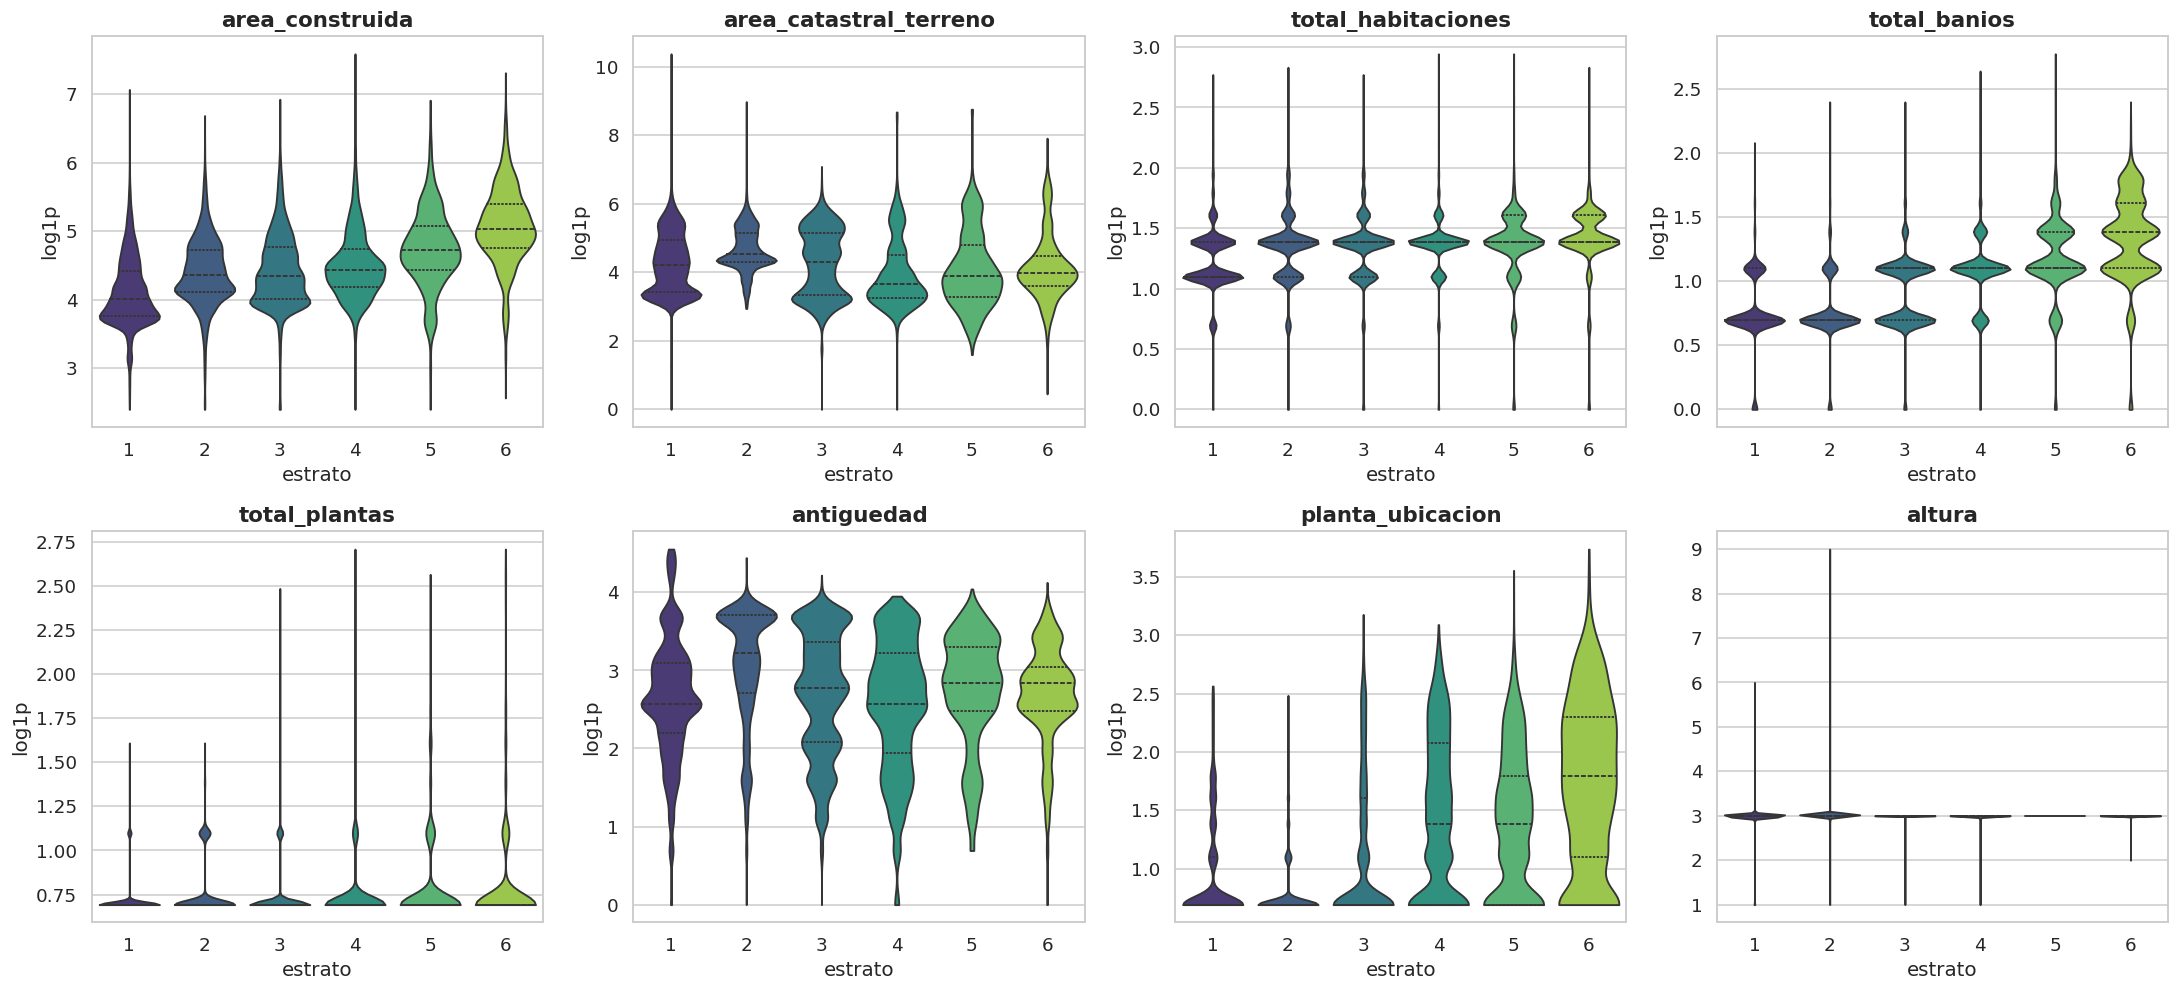

In [4]:
# Figura: violines de cada numérica por estrato (escala log1p si aplica). Se ve
# la forma completa de la distribución en cada clase, no solo la mediana, y si
# la variable crece de forma monótona con el estrato.
ncol = 4
nfil = int(np.ceil(len(nums) / ncol))
fig, axes = plt.subplots(nfil, ncol, figsize=(20, 4.6 * nfil))
# Muestra estratificada de 40 000 filas (mismas proporciones de estrato que
# train): suficiente para estimar la densidad y mucho más rápida de dibujar.
m = S.muestra_estratificada(train, 40_000)
for ax, c in zip(axes.ravel(), nums):
    y = np.log1p(m[c].clip(lower=0)) if c in num_log else m[c]
    # cut=0: la densidad no se extiende más allá de los datos observados;
    # inner="quartile" dibuja Q1, mediana y Q3; density_norm="width" da el
    # mismo ancho a todos los violines, para comparar formas y no tamaños de clase.
    sns.violinplot(x=m[C.OBJETIVO], y=y, ax=ax, hue=m[C.OBJETIVO], palette=G.PALETA_ESTRATO,
                   legend=False, cut=0, inner="quartile", density_norm="width")
    ax.set_title(c)
    ax.set_xlabel("estrato")
    ax.set_ylabel("log1p" if c in num_log else "")
for ax in axes.ravel()[len(nums):]:
    ax.axis("off")  # oculta los paneles sobrantes de la grilla
fig.tight_layout()
G.guardar(fig, "06_violines_objetivo")
plt.show()

In [5]:
# Numérica vs. objetivo: Kruskal-Wallis (alternativa no paramétrica al ANOVA de
# una vía; no supone normalidad, adecuada con las colas largas del cap. 5) y su
# tamaño de efecto η²_H = (H − k + 1)/(n − k). E.kruskal_eta2 también devuelve
# el Spearman con el estrato (dirección, ya que el estrato es ordinal) y la
# mediana por estrato (para ver si la relación es monótona).
kw = pd.DataFrame([E.kruskal_eta2(train, c, C.OBJETIVO) for c in nums + C.ESPACIALES]).set_index("variable")
# Corrección de Holm por comparaciones múltiples (se hacen 11 pruebas a la vez).
kw["p_Holm"] = E.ajuste_holm(kw["p"])
# Se ordena por tamaño de efecto, no por p: con n ≈ 220 000 todos los p son
# minúsculos y no discriminan; η²_H sí indica cuánto se asocia al estrato.
kw = kw.sort_values("eta2_H", ascending=False)
kw

,n,H,p,eta2_H,efecto,spearman_con_objetivo,mediana_e1,mediana_e2,mediana_e3,mediana_e4,mediana_e5,mediana_e6,p_Holm
variable,,,,,,,,,,,,,
y_km,218870,"109,580.665",0.000,0.501,grande,0.658,-3.505,-4.496,-0.770,2.290,2.848,3.180,0.000
dist_centro_km,218870,"70,929.681",0.000,0.324,grande,-0.427,7.430,5.935,3.992,5.401,5.911,5.775,0.000
total_banios,218842,"68,307.939",0.000,0.312,grande,0.524,1.000,1.000,2.000,2.000,2.000,3.000,0.000
x_km,218870,"56,221.316",0.000,0.257,grande,0.200,-5.791,-3.057,-2.460,-4.358,-5.243,-4.743,0.000
planta_ubicacion,218633,"45,426.893",0.000,0.208,grande,0.380,1.000,1.000,1.000,3.000,3.000,5.000,0.000
area_construida,218870,"39,555.037",0.000,0.181,grande,0.388,54.000,76.000,77.000,83.000,113.000,152.000,0.000
total_habitaciones,218599,"16,681.876",0.000,0.076,mediano,0.255,2.000,3.000,3.000,3.000,3.000,3.000,0.000
area_catastral_terreno,218870,"16,267.670",0.000,0.074,mediano,-0.152,66.000,90.900,72.150,37.770,45.740,51.900,0.000
antiguedad,218741,"12,359.206",0.000,0.056,pequeño,-0.055,12.000,24.000,15.000,12.000,16.000,16.000,0.000


```{admonition} Cómo leer η²_H
:class: note
η²_H = (H − k + 1)/(n − k) es la proporción de la variabilidad de los rangos
explicada por el estrato. Umbrales usuales: < 0.01 trivial, 0.01–0.06
pequeño, 0.06–0.14 mediano, > 0.14 grande. La columna de Spearman indica la
**dirección** (¿crece la variable con el estrato?) y las medianas por
estrato muestran si la relación es monótona.
```

## 6.3 Categóricas vs. objetivo

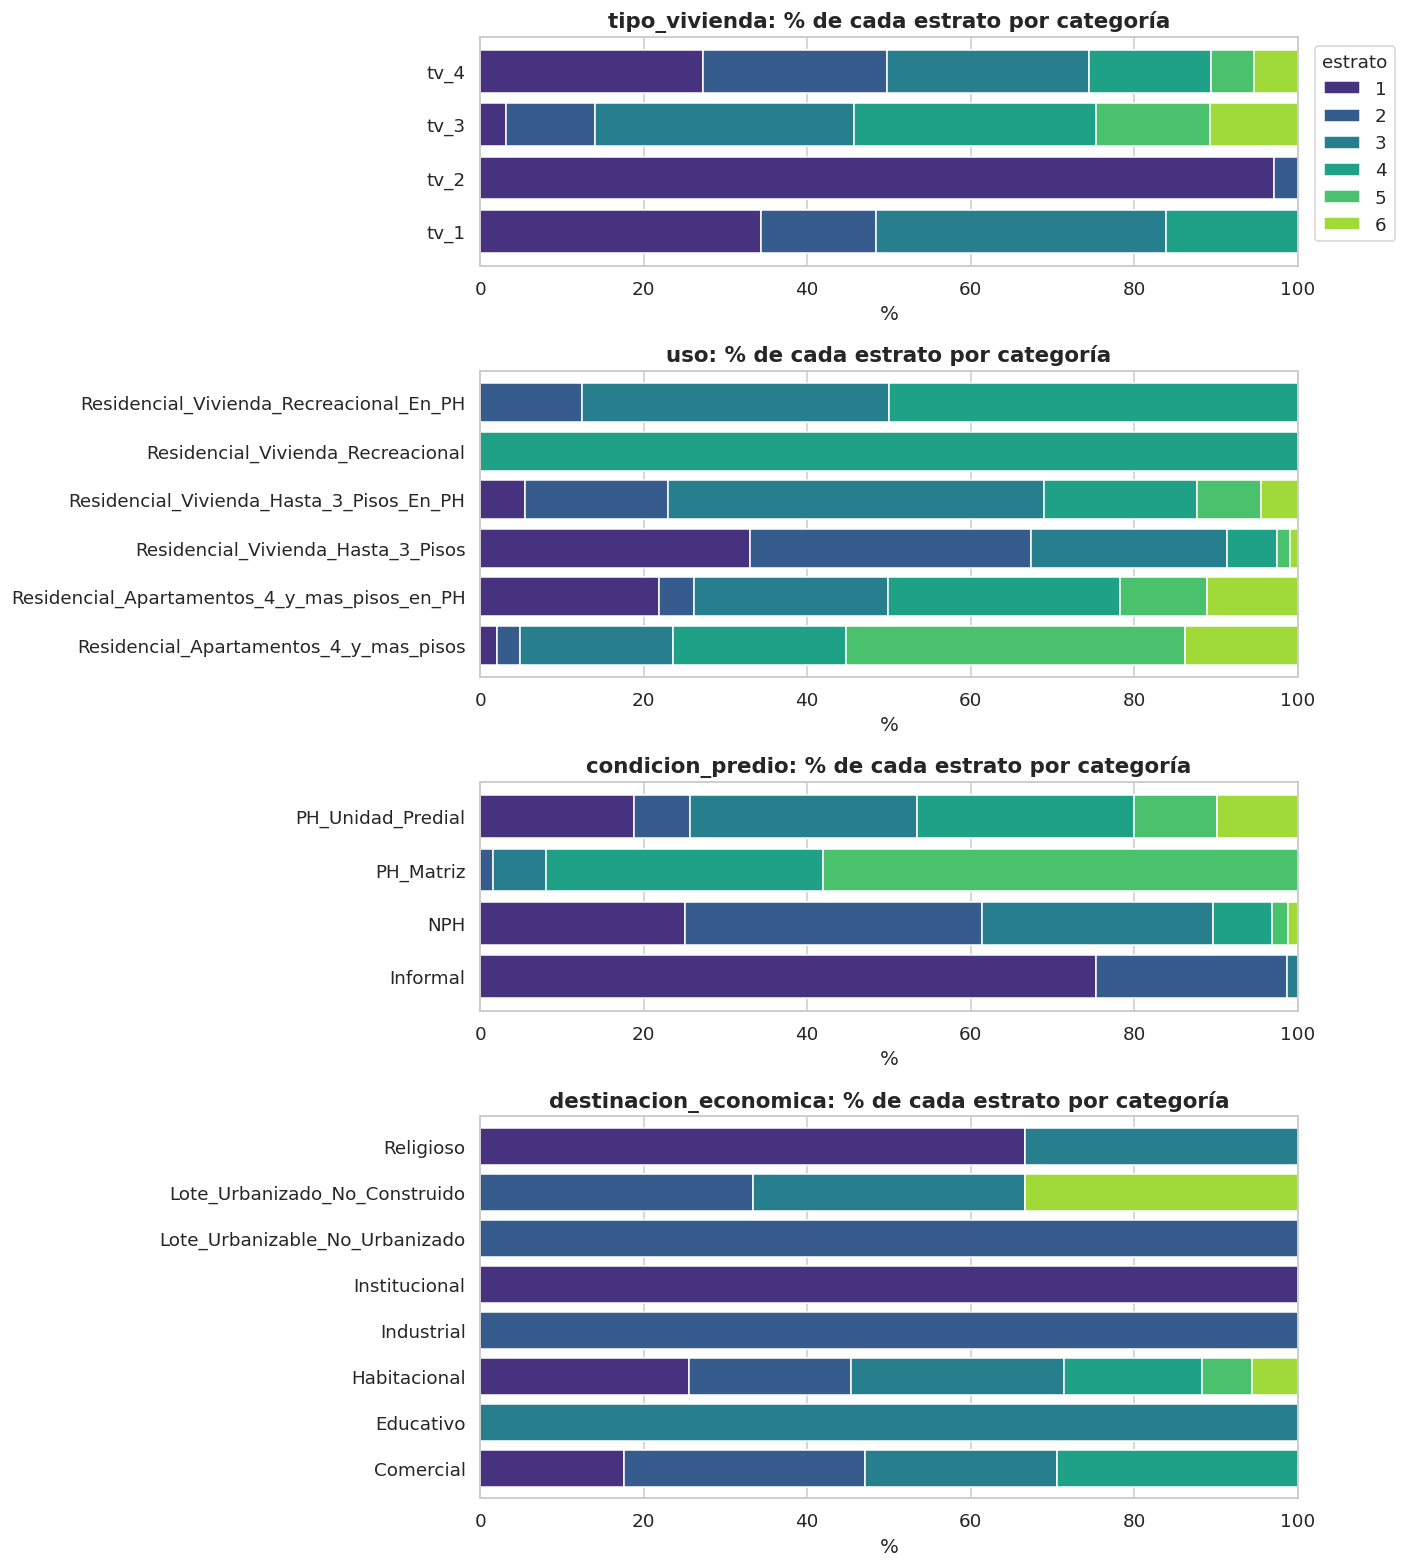

In [6]:
# Figura: barras apiladas al 100 % con la composición de estratos dentro de
# cada categoría (hasta 10 categorías por variable). Si la categórica no se
# asociara con el estrato, todas las barras tendrían la misma composición.
fig, axes = plt.subplots(len(cats), 1, figsize=(13, sum(1.3 + 0.42 * min(train[c].nunique(), 10) for c in cats)),
                         gridspec_kw={"height_ratios": [min(train[c].nunique(), 10) + 2 for c in cats]})
for ax, c in zip(np.atleast_1d(axes), cats):
    top = train[c].value_counts().head(10).index  # 10 categorías más frecuentes
    # normalize="index": % por fila (distribución del estrato dada la categoría).
    t = pd.crosstab(train.loc[train[c].isin(top), c], train[C.OBJETIVO], normalize="index").mul(100)
    t.plot.barh(stacked=True, ax=ax, color=[G.PALETA_ESTRATO[k] for k in t.columns], legend=False, width=0.8)
    ax.set_title(f"{c}: % de cada estrato por categoría")
    ax.set_xlabel("%")
    ax.set_ylabel("")
# Una sola leyenda (en el primer panel, fuera del eje) para no repetirla.
np.atleast_1d(axes)[0].legend(title="estrato", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
G.guardar(fig, "06_categoricas_objetivo")
plt.show()

In [7]:
# Categórica vs. objetivo: prueba χ² de independencia sobre la tabla de
# contingencia y V de Cramér como tamaño de efecto (0 = independencia,
# 1 = asociación perfecta). E.cramers_v aplica la corrección de sesgo de
# Bergsma (2013), porque la V sin corregir se infla con muchas categorías.
filas = []
for c in cats:
    # Los nulos se tratan como una categoría más ("faltante"): si faltar un
    # dato se asocia con el estrato, eso también es información.
    r = E.cramers_v(train[c].fillna("faltante"), train[C.OBJETIVO])
    filas.append({"variable": c, "categorías": train[c].nunique(), "chi2": r["chi2"], "gl": r["gl"],
                  "p": r["p"], "V_Cramér": r["V"], "lectura": E.interpretar_v(r["V"])})
chi_obj = pd.DataFrame(filas).set_index("variable")
chi_obj["p_Holm"] = E.ajuste_holm(chi_obj["p"])  # Holm dentro de esta familia de pruebas
chi_obj.sort_values("V_Cramér", ascending=False)

,categorías,chi2,gl,p,V_Cramér,lectura,p_Holm
variable,,,,,,,
condicion_predio,4,"72,809.688",15,0.000,0.333,moderada,0.000
uso,6,"62,828.235",25,0.000,0.240,débil,0.000
tipo_vivienda,4,"31,583.682",15,0.000,0.219,débil,0.000
destinacion_economica,8,34.954,35,0.470,0.000,despreciable,0.470


## 6.4 Categóricas vs. categóricas

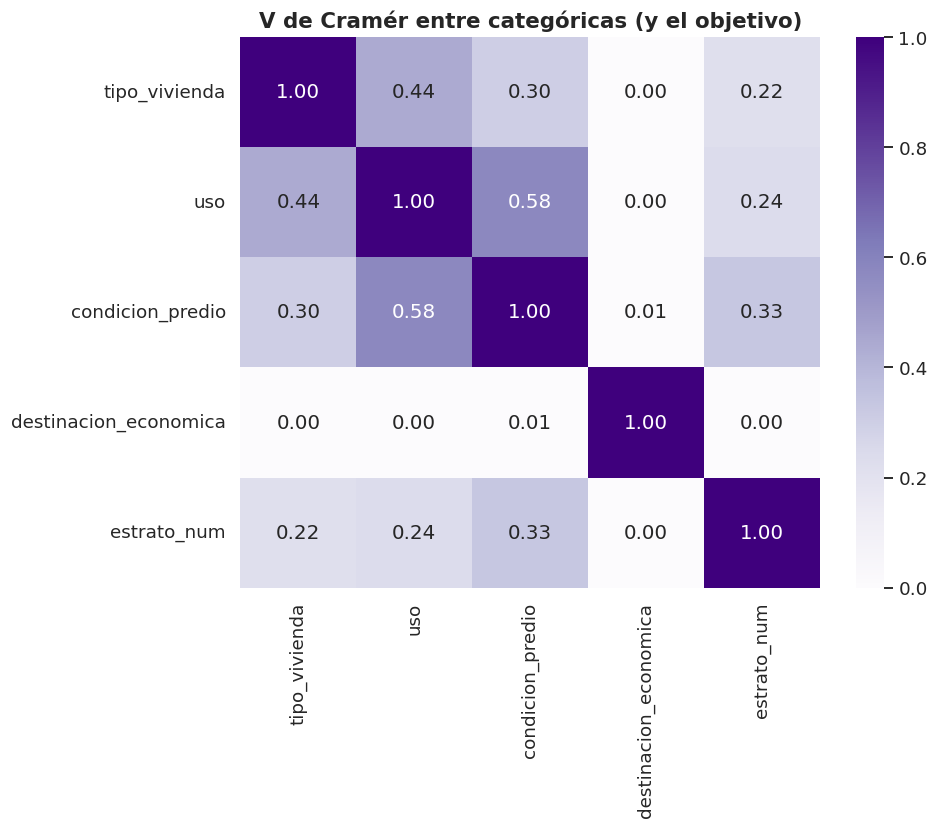

In [8]:
# Matriz de V de Cramér entre todas las categóricas (y el estrato) para
# detectar redundancias entre predictoras, p. ej. uso y condicion_predio, que
# codifican ambas el régimen de propiedad horizontal.
todas = cats + [C.OBJETIVO]
# Diagonal = 1 (cada variable consigo misma); la matriz es simétrica.
Vm = pd.DataFrame(np.eye(len(todas)), index=todas, columns=todas)
pv = []  # (var1, var2, p, V): los p se reutilizan en la corrección global (6.9)
for i, a in enumerate(todas):
    for b in todas[i + 1:]:  # solo la mitad superior; la otra se copia
        r = E.cramers_v(train[a].fillna("faltante"), train[b].fillna("faltante"))
        Vm.loc[a, b] = Vm.loc[b, a] = r["V"]
        pv.append((a, b, r["p"], r["V"]))
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(Vm, annot=True, fmt=".2f", cmap="Purples", vmin=0, vmax=1, ax=ax)
ax.set_title("V de Cramér entre categóricas (y el objetivo)")
G.guardar(fig, "06_cramer")
plt.show()

In [9]:
# Tabla de contingencia uso × condicion_predio (% por fila) para ver de dónde
# sale la V alta: si las categorías "…en_PH" de uso caen casi siempre en
# PH_Unidad_Predial, ambas variables dicen casi lo mismo.
if "uso" in cats and "condicion_predio" in cats:
    print("Tabla de contingencia uso × condicion_predio (% por fila):")
    display(pd.crosstab(train["uso"], train["condicion_predio"], normalize="index").mul(100).round(1))

Tabla de contingencia uso × condicion_predio (% por fila):


condicion_predio,Informal,NPH,PH_Matriz,PH_Unidad_Predial
uso,,,,
Residencial_Apartamentos_4_y_mas_pisos,0.000,32.900,0.000,67.100
Residencial_Apartamentos_4_y_mas_pisos_en_PH,0.000,0.000,0.100,99.900
Residencial_Vivienda_Hasta_3_Pisos,16.000,84.000,0.000,0.000
Residencial_Vivienda_Hasta_3_Pisos_En_PH,0.000,0.000,0.000,100.000
Residencial_Vivienda_Recreacional,0.000,100.000,0.000,0.000
Residencial_Vivienda_Recreacional_En_PH,0.000,0.000,0.000,100.000


## 6.5 Categóricas vs. numéricas (predictoras entre sí)

¿Cambian las características físicas según el régimen/uso? (Kruskal-Wallis y
η²_H.) Sirve para detectar redundancia entre una categórica y una numérica.

In [10]:
# Categórica vs. numérica entre predictoras: Kruskal-Wallis de cada numérica
# agrupada por cada categórica y su η²_H. Un η²_H grande indica que la
# categórica "explica" buena parte de la numérica (posible redundancia).
filas = []
for c in cats:
    for v in nums:
        # Se crea una columna auxiliar _g con la categórica (nulos = "faltante").
        # ordinal=False: las categorías no tienen orden, así que no se calcula
        # Spearman (solo tiene sentido con el estrato).
        r = E.kruskal_eta2(train.assign(_g=train[c].fillna("faltante")), v, "_g", ordinal=False)
        filas.append({"categórica": c, "numérica": v, "eta2_H": r["eta2_H"], "p": r["p"],
                      "efecto": r["efecto"]})
cat_num = pd.DataFrame(filas)
cat_num["p_Holm"] = E.ajuste_holm(cat_num["p"])
# Se presenta como matriz numérica × categórica con gradiente de color en η²_H.
cat_num.pivot(index="numérica", columns="categórica", values="eta2_H").style.background_gradient(cmap="Greens").format("{:.3f}")

categórica,condicion_predio,destinacion_economica,tipo_vivienda,uso
numérica,,,,
altura,0.003,0.000,0.103,0.004
antiguedad,0.054,0.000,0.041,0.062
area_catastral_terreno,0.549,0.000,0.129,0.616
area_construida,0.096,0.000,0.121,0.078
planta_ubicacion,0.522,0.000,0.087,0.660
total_banios,0.168,0.000,0.024,0.165
total_habitaciones,0.049,0.000,0.020,0.011
total_plantas,0.009,0.000,0.029,0.075


## 6.6 Predictoras vs. objetivo: información mutua

La información mutua (MI) capta relaciones **no lineales y no monótonas** que
Spearman o η² pueden subestimar. Se reporta también MI / H(estrato): la
fracción de la incertidumbre del estrato que reduce conocer la variable. Por
costo computacional (estimador por k vecinos) se calcula sobre una muestra
estratificada de train.

In [11]:
# Información mutua (MI) entre cada predictora y el estrato. A diferencia de
# Spearman o η²_H, la MI detecta cualquier dependencia, incluso no monótona
# (formas en U). Se estima sobre una muestra estratificada de train
# (C.N_MUESTRA_MI filas) porque el estimador por k vecinos es costoso.
m = S.muestra_estratificada(train, C.N_MUESTRA_MI)
X = pd.DataFrame(index=m.index)
discretas = []  # máscara que indica al estimador qué columnas son discretas
for c in nums + C.ESPACIALES:
    # mutual_info_classif no acepta NaN; se imputa con la mediana de la muestra.
    X[c] = m[c].fillna(m[c].median())
    # Los conteos se tratan como discretos (estimador por frecuencias); las
    # continuas usan el estimador por k vecinos (Ross 2014, variante de Kraskov).
    discretas.append(c in ["total_habitaciones", "total_banios", "total_plantas", "planta_ubicacion"])
for c in cats:
    # Las categóricas se codifican como enteros; al marcarlas como discretas,
    # el orden arbitrario de los códigos no afecta a la MI.
    X[c] = m[c].fillna("faltante").astype("category").cat.codes
    discretas.append(True)
# random_state fijo: el estimador añade un ruido pequeño a las continuas.
mi = mutual_info_classif(X, m[C.OBJETIVO], discrete_features=np.array(discretas), random_state=C.SEED)
# Entropía del estrato en nats (log natural, mismas unidades que la MI):
# MI / H(Y) es la fracción de la incertidumbre del estrato que se reduce.
H = E.entropia(m[C.OBJETIVO])
mi_tabla = pd.DataFrame({"MI (nats)": mi, "MI / H(Y)": mi / H}, index=X.columns).sort_values("MI (nats)",
                                                                                         ascending=False)
mi_tabla

,MI (nats),MI / H(Y)
y_km,1.046,0.633
dist_centro_km,1.001,0.606
x_km,0.975,0.590
area_catastral_terreno,0.664,0.401
area_construida,0.270,0.163
total_banios,0.195,0.118
condicion_predio,0.177,0.107
antiguedad,0.172,0.104
uso,0.158,0.096
planta_ubicacion,0.128,0.077


## 6.7 Ranking consolidado de asociación con el estrato

In [12]:
# Ranking consolidado: une en una tabla la MI con las medidas de efecto
# calculadas antes. Pandas alinea por índice (nombre de variable), así que
# η²_H y Spearman quedan en NaN para las categóricas y la V de Cramér en NaN
# para las numéricas: cada medida solo aplica a su tipo de variable.
rank = mi_tabla.copy()
rank["η²_H (num.)"] = kw["eta2_H"]
rank["Spearman (num.)"] = kw["spearman_con_objetivo"]
rank["V Cramér (cat.)"] = chi_obj["V_Cramér"]
rank["tipo"] = ["categórica" if c in cats else ("espacial" if c in C.ESPACIALES else "numérica") for c in rank.index]
rank

,MI (nats),MI / H(Y),η²_H (num.),Spearman (num.),V Cramér (cat.),tipo
y_km,1.046,0.633,0.501,0.658,NaN,espacial
dist_centro_km,1.001,0.606,0.324,-0.427,NaN,espacial
x_km,0.975,0.590,0.257,0.200,NaN,espacial
area_catastral_terreno,0.664,0.401,0.074,-0.152,NaN,numérica
area_construida,0.270,0.163,0.181,0.388,NaN,numérica
total_banios,0.195,0.118,0.312,0.524,NaN,numérica
condicion_predio,0.177,0.107,NaN,NaN,0.333,categórica
antiguedad,0.172,0.104,0.056,-0.055,NaN,numérica
uso,0.158,0.096,NaN,NaN,0.240,categórica
planta_ubicacion,0.128,0.077,0.208,0.380,NaN,numérica


## 6.8 Multicolinealidad (VIF)

VIF_j = 1 / (1 − R²_j), con R²_j de regresar la variable j sobre las demás.
Se calcula con las numéricas en la escala en que entrarán al modelo (log1p
para las asimétricas) e imputadas con la mediana de train. Umbrales usuales:
< 5 aceptable, 5–10 vigilar, > 10 multicolinealidad alta.

In [13]:
# VIF de las numéricas físicas en la escala del modelo: log1p en las
# asimétricas (las colas largas distorsionarían las regresiones auxiliares) e
# imputación con la mediana de train (como hará el Pipeline).
Z = train[nums].copy()
for c in num_log:
    Z[c] = np.log1p(Z[c].clip(lower=0))
Z = Z.fillna(Z.median())
# E.vif estandariza y regresa cada variable sobre las demás con mínimos
# cuadrados: VIF_j = 1/(1 − R²_j).
tabla_vif = E.vif(Z, nums)
tabla_vif

,R2_con_las_demás,VIF,lectura
variable,,,
area_catastral_terreno,0.637,2.758,aceptable
area_construida,0.610,2.562,aceptable
total_banios,0.513,2.054,aceptable
planta_ubicacion,0.487,1.948,aceptable
total_habitaciones,0.461,1.854,aceptable
total_plantas,0.080,1.086,aceptable
antiguedad,0.067,1.071,aceptable
altura,0.008,1.008,aceptable


In [14]:
# Mismo VIF añadiendo las coordenadas: interesa saber si x_km, y_km y
# dist_centro_km son redundantes entre sí (la distancia al centro es función
# geométrica de x e y). Solo se muestran las filas de las espaciales.
Z2 = pd.concat([Z, train[C.ESPACIALES]], axis=1)
vif_esp = E.vif(Z2, nums + C.ESPACIALES)
vif_esp.loc[C.ESPACIALES]

,R2_con_las_demás,VIF,lectura
variable,,,
x_km,0.814,5.390,moderada (vigilar)
y_km,0.484,1.938,aceptable
dist_centro_km,0.799,4.968,aceptable


**Regla de decisión:** mientras el VIF máximo sea > 10, se elimina, entre las
variables con VIF > 10, la que tenga **menor asociación con el estrato**
(η²_H). Así se reduce la redundancia perdiendo la menor información posible.

In [15]:
# Eliminación iterativa por VIF: se recalcula el VIF tras cada retirada porque
# quitar una variable cambia el VIF de las demás. Entre las de VIF > 10 se
# retira la menos asociada al estrato (menor η²_H), para perder la mínima
# información útil para predecir.
restantes = list(nums)
eliminadas = []
while True:
    t = E.vif(Z, restantes)
    altas = t[t["VIF"] > 10]
    if altas.empty:
        break  # ya no queda multicolinealidad alta
    peor = kw.loc[altas.index, "eta2_H"].idxmin()
    eliminadas.append(peor)
    restantes.remove(peor)
print("Eliminadas por multicolinealidad:", eliminadas or "ninguna")
# Se registra la decisión (aunque la lista esté vacía) para trazabilidad.
C.guardar_decision("excluir_multicolinealidad", eliminadas,
                   "VIF > 10 (cap. 6.8); se retira la de menor η²_H con el estrato.")

Eliminadas por multicolinealidad: ninguna
[decisión registrada] excluir_multicolinealidad = []
   motivo: VIF > 10 (cap. 6.8); se retira la de menor η²_H con el estrato.


## 6.9 Todas las pruebas con corrección por comparaciones múltiples

In [16]:
# Corrección global: se reúnen en una sola familia todas las pruebas contra el
# estrato (Kruskal-Wallis y χ²) y las χ² entre categóricas, y se ajustan con
# Holm (controla el error de familia, FWER) y Benjamini-Hochberg (controla la
# tasa de falsos descubrimientos, FDR, menos conservador).
familia = pd.concat([
    kw[["p"]].assign(prueba="Kruskal-Wallis vs estrato"),
    chi_obj[["p"]].assign(prueba="chi² vs estrato"),
    # De pv se excluyen los pares con el objetivo, que ya están en chi_obj.
    pd.DataFrame([(f"{a}×{b}", p) for a, b, p, _ in pv if C.OBJETIVO not in (a, b)], columns=["par", "p"]).set_index("par").assign(prueba="chi² cat×cat"),
])
familia["p_Holm"] = E.ajuste_holm(familia["p"])
familia["p_BH (FDR)"] = E.ajuste_bh(familia["p"])
# Recordatorio: los p suponen filas independientes (no lo son: unidades de un
# mismo edificio, autocorrelación espacial), así que incluso tras Holm son
# optimistas; las decisiones se basan en los tamaños de efecto.
familia["significativa (Holm 5%)"] = familia["p_Holm"] < 0.05
print(f"{familia['significativa (Holm 5%)'].sum()} de {len(familia)} pruebas significativas tras Holm")
familia.sort_values("p")

18 de 21 pruebas significativas tras Holm


,p,prueba,p_Holm,p_BH (FDR),significativa (Holm 5%)
y_km,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
dist_centro_km,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
total_banios,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
x_km,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
planta_ubicacion,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
area_construida,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
total_habitaciones,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
area_catastral_terreno,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
antiguedad,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True
total_plantas,0.000,Kruskal-Wallis vs estrato,0.000,0.000,True


## 6.10 Interpretación y selección preliminar de variables

```{admonition} Interpretación
:class: note
- **La ubicación domina.** Por tamaño de efecto (η²_H de Kruskal-Wallis),
  la variable más asociada al estrato es **`y_km`** (eje norte-sur,
  η² = 0.50, Spearman 0.66), seguida de la distancia al centro (0.32) y
  `x_km` (0.26). Entre las físicas destacan **baños** (η² = 0.31, Spearman
  0.52), **piso de ubicación** (0.21) y **área construida** (0.18): mediana
  de 54 m² en estrato 1 frente a 152 m² en estrato 6. Habitaciones (0.076) y
  terreno (0.074) tienen efectos medianos; antigüedad (0.056) y plantas
  (0.018) pequeños, y `altura` es trivial (0.005).
- **No todo es monótono.** El terreno tiene Spearman negativo (−0.15) y sus
  medianas por estrato suben de 1 a 2 (66 → 90.9 m²) y luego caen en 4–6
  (38–52 m²): en los estratos altos predominan apartamentos PH con cuotas de
  terreno pequeñas. Algo parecido pasa con `x_km` y la distancia al centro,
  cuyas medianas no siguen el orden del estrato. Una regresión logística con
  términos lineales no captura bien estas formas en U.
- **Información mutua.** Coincide en poner la ubicación arriba (MI/H(Y) de
  0.59–0.63) pero sube mucho al terreno (0.40). Hay que leer la MI con
  cautela: coordenadas y terreno se repiten exactamente en todas las unidades
  de un edificio, y como el estrato casi no varía dentro del edificio
  (ICC = 0.992), el estimador de MI por vecinos premia variables que
  "identifican el edificio", más que relaciones generalizables.
- **Categóricas.** `condicion_predio` (V = 0.33, moderada), `uso` (0.24) y
  `tipo_vivienda` (0.22) superan el umbral de 0.1; `destinacion_economica`
  tiene V = 0 (p = 0.47) y se descarta.
- **Redundancias.** `uso` y `condicion_predio` están muy asociadas: las
  categorías "…en_PH" son 99.9–100 % `PH_Unidad_Predial`. Con regularización L2 la
  logística tolera esta redundancia para predecir, pero sus coeficientes
  individuales se interpretan con cautela. Entre numéricas **no hay
  multicolinealidad preocupante**: todos los VIF < 3 (el mayor, terreno con
  2.76); solo `x_km` llega a 5.4 (y `dist_centro_km` a 5.0) cuando entran
  las espaciales, por su relación geométrica.
- **Pruebas múltiples.** 18 de 21 pruebas siguen significativas tras Holm;
  con n ≈ 220 000 casi todo es "significativo", por eso las decisiones se
  toman con los **tamaños de efecto**, no con los p-valores. Además, la
  dependencia entre unidades de un mismo edificio hace que estos p-valores
  sean optimistas (el n efectivo es mucho menor, cap. 1).
- **Selección preliminar:** las 8 numéricas (ninguna eliminada por VIF), las
  3 categóricas con V ≥ 0.1 y las 3 espaciales (justificadas en el cap. 8).
  `altura` se conserva por ahora, aunque aporta muy poco. La lista final se
  fija tras la auditoría de fuga (cap. 9).
```

In [17]:
# Selección preliminar registrada para el modelo: categóricas con V ≥ 0.1
# (umbral de asociación "débil" o mayor; por debajo es despreciable) y
# numéricas que sobrevivieron al filtro de VIF. La lista definitiva se fija
# tras la auditoría de fuga (cap. 9).
cats_utiles = chi_obj.index[chi_obj["V_Cramér"] >= 0.1].tolist()
C.guardar_decision("categoricas_preliminares", cats_utiles,
                   "Categóricas con V de Cramér ≥ 0.1 con el estrato (cap. 6.3).")
C.guardar_decision("numericas_preliminares", [c for c in nums if c not in eliminadas],
                   "Numéricas tras quitar las de VIF alto (cap. 6.8).")

[decisión registrada] categoricas_preliminares = ['tipo_vivienda', 'uso', 'condicion_predio']
   motivo: Categóricas con V de Cramér ≥ 0.1 con el estrato (cap. 6.3).
[decisión registrada] numericas_preliminares = ['area_construida', 'area_catastral_terreno', 'total_habitaciones', 'total_banios', 'total_plantas', 'antiguedad', 'planta_ubicacion', 'altura']
   motivo: Numéricas tras quitar las de VIF alto (cap. 6.8).
